In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:,i_time] = maxI_
    return control_

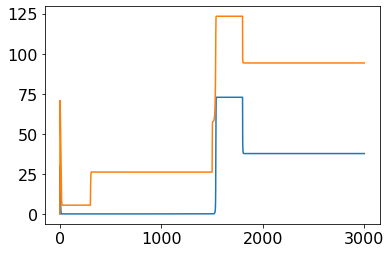

[[2.3474e-04 2.6062e+01]
 [3.7674e+01 9.4217e+01]]


In [3]:
aln = ALNModel()

aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 2.5

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

state = aln.getZeroState()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

output = aln.output_vars

for i in range(len(output)):
    state[:,i,:] = aln[output[i]][:,:]
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = np.mean(state[0,0,3000:15000]) # low state exc
steady_rates[0,1] = np.mean(state[0,1,3000:15000]) # low state inh
steady_rates[1,0] = np.mean(state[0,0,19500:]) # high state exc
steady_rates[1,1] = np.mean(state[0,1,19500:]) #high state inh

print(steady_rates)

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] * 1.01
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1] * 1.01

low state vars =  [ 8.3127e-005  2.5847e+001 -3.3072e-001  1.0327e+000  0.0000e+000
  1.6420e-005  7.9023e-001  1.5346e-005  8.7951e-001  1.0135e-006
  2.5945e-003  8.8534e-007  1.9317e-003  2.3986e-264  1.7990e-264
  1.5030e+000  1.4869e+000 -7.0969e+001  2.1153e+001  2.3058e+000]


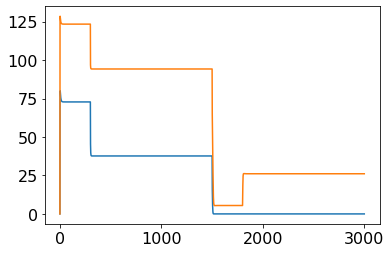

In [4]:
control0 = step_control(maxI_ = -1.)
aln.run(control = control0)
plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0] * 0.99
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1] * 0.99

print("low state vars = ", low_state_vars)

### State switching task in bistability regime: Switch from up to down state

In [11]:
dur = 5.
dur_pre = 5.
dur_post = 5.
aln.params.duration = dur

control0 = aln.getZeroControl()

# set high state rates as target
target_hl = aln.getZeroTarget()
target_hl[:,0,:] = steady_rates[0,0]
target_hl[:,1,:] = steady_rates[0,1]

tol = 1e-12
incl_step = int(1. + aln.params.duration/aln.params.dt)
start_step = 10.
test_step = 1e-6

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

alg = "A1"
#alg = "A2"

plot_only = False

init_inf_hl = control0.copy()
#init_inf_hl[:,:,:2] = -100.

init_1nA_hl = control0.copy()
#init_1nA_hl[:,:,:10] = -5.

init_inf_lh = - init_inf_hl

init_1nA_lh = - init_1nA_hl

In [77]:
# D: precision & energy equally penalize, max 1nA control
cost.setParams(1.0, 1.0, 0.)
max_cntrl = 1. * 5.

def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,0] = vars[sv]
                else:
                    aln.params[init_vars[iv]][0] = vars[sv]
                
opt_params = {"max_it": max_it,
              "tol": tol,
              "incl_step": incl_step,
              "start_step": start_step,
              "test_step": test_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
}

set cost params


In [84]:
setinitvars(high_state_vars)
max_it = 7
alg = "A1"

if not plot_only:
    if alg == "A1":
        bestControlD, bestStateD, costD, runtimeD, grad = aln.A1(init_1nA_hl, target_hl, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    elif alg == "A2":
        bestControlD, bestStateD, costD, runtimeD = aln.A2(control0, target_hl, max_iteration_ = max_it,
                    tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                    max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

    resultD = {"Opt_control": bestControlD,
              "Opt_state": bestStateD,
              "costArray": costD,
              "runtimeArray": runtimeD,    
    }

    dump_dicts = [opt_params, aln.params, resultD]
    filename = str("D_" + alg + ".p")
    pickle.dump( dump_dicts, open( filename, "wb" ) )

RUN  0 , total integrated cost =  15466.745250817374
RUN  1 , total integrated cost =  1651.3224787449658
RUN  2 , total integrated cost =  996.5190681153795
RUN  3 , total integrated cost =  908.0259601783921
RUN  4 , total integrated cost =  868.2300890749635
RUN  5 , total integrated cost =  840.3429308034473
RUN  6 , total integrated cost =  823.7799914742341


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  813.7697038221016
Improved over  7  iterations by  94.73858468200285  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) 290.9813632368285
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([7], dtype=int64)) -76.79947525314559
Problem in initial value trasfer for  sigmae_f
1.5015055328885818
1.5015055561808024
Problem in initial value trasfer for  sigmai_f
1.5009956705424545
1.500995696410558
Problem in initial value trasfer for  tau_exc
1.4948511079271753
1.494906763790026
Problem in initial value trasfer for  tau_inh
0.4410379193974131
0.44103800183003217


In [ ]:
plotFunc.plot_convergence(costD, path, str("p1_e1_u1nA_HighLow_cost_" + alg) )

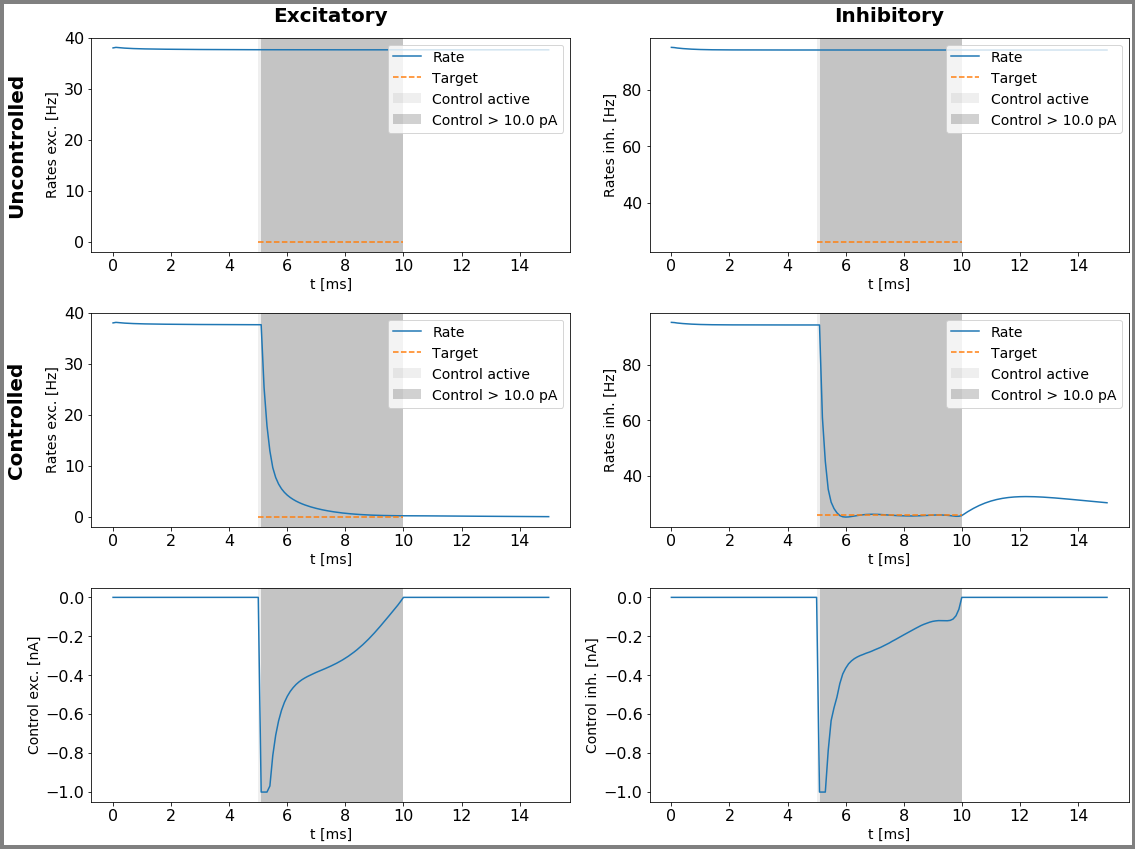

In [14]:
plotFunc.plot_control(aln, bestControlD, dur, dur_pre, dur_post, high_state_vars, target_hl,
                      path, filename_ = str('p1_e1_u1nA_HighLow_' + alg))

In [115]:
cntrl1 = init_1nA_hl
alg = "A1"

max_it = 20
loop_it = 10
costA1 = np.zeros(max_it*loop_it + 1)
runtimeA1 = np.zeros(max_it*loop_it + 1)

RUN  0 , total integrated cost =  15466.745250817374
RUN  1 , total integrated cost =  1651.3224787449658
RUN  2 , total integrated cost =  996.5190681153795
RUN  3 , total integrated cost =  908.0259601783921
RUN  4 , total integrated cost =  868.2300890749635
RUN  5 , total integrated cost =  840.3429308034473
RUN  6 , total integrated cost =  823.7799914742341
RUN  7 , total integrated cost =  813.7697038221016
RUN  8 , total integrated cost =  807.1133555371915
RUN  9 , total integrated cost =  802.33662101108
RUN  10 , total integrated cost =  798.7237452098816
RUN  11 , total integrated cost =  795.8532769505181
RUN  12 , total integrated cost =  793.7133212893029
RUN  13 , total integrated cost =  792.2591959192106
RUN  14 , total integrated cost =  791.0571646219792
RUN  15 , total integrated cost =  790.2549220795812
RUN  16 , total integrated cost =  789.588923299613
RUN  17 , total integrated cost =  788.9868656201838
RUN  18 , total integrated cost =  788.4450741382093
RUN 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  20 , total integrated cost =  787.4718966299928
Improved over  20  iterations by  94.90861274392311  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) 328.893895552828
min value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([30], dtype=int64)) -1.2436342071510664
Problem in initial value trasfer for  sigmae_f
1.5015055328885818
1.5015055561808024
Problem in initial value trasfer for  sigmai_f
1.5009956705424545
1.500995696410558
Problem in initial value trasfer for  tau_exc
1.4948511079271753
1.494906763790026
Problem in initial value trasfer for  tau_inh
0.4410379193974131
0.44103800183003217
RUN  0 , total integrated cost =  787.4719238347681
RUN  1 , total integrated cost =  787.0364370369005
RUN  2 , total integrated cost =  786.6347904767367
RUN  3 , total integrated cost =  786.3868945239317
RUN  4 , total integrated cost =  786.1513908105455
RUN  5 , total int

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  20 , total integrated cost =  782.4514464447316
Improved over  20  iterations by  0.6375436682984486  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) 322.10835918749507
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([6], dtype=int64)) -1.4055501191353512
Problem in initial value trasfer for  sigmae_f
1.5015055328885818
1.5015055561808024
Problem in initial value trasfer for  sigmai_f
1.5009956705424545
1.500995696410558
Problem in initial value trasfer for  tau_exc
1.4948511079271753
1.494906763790026
Problem in initial value trasfer for  tau_inh
0.4410379193974131
0.44103800183003217
RUN  0 , total integrated cost =  782.452097182914
RUN  1 , total integrated cost =  782.2382877026971
RUN  2 , total integrated cost =  782.2011915358821
RUN  3 , total integrated cost =  782.1771665540406
RUN  4 , total integrated cost =  782.147913464839
RUN  5 , total int

...

RUN  20 , total integrated cost =  781.3405339589705
Improved over  20  iterations by  6.235030826928778e-05  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) 321.79063262930777
min value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([9], dtype=int64)) -0.01252343230479136
Problem in initial value trasfer for  sigmae_f
1.5015055328885818
1.5015055561808024
Problem in initial value trasfer for  sigmai_f
1.5009956705424545
1.500995696410558
Problem in initial value trasfer for  tau_exc
1.4948511079271753
1.494906763790026
Problem in initial value trasfer for  tau_inh
0.4410379193974131
0.44103800183003217
RUN  0 , total integrated cost =  781.3405339923565
RUN  1 , total integrated cost =  781.3405302651099
RUN  2 , total integrated cost =  781.3405298751595
RUN  3 , total integrated cost =  781.3405297972878
RUN  4 , total integrated cost =  781.3405297221962
RUN  5 , tot

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  20 , total integrated cost =  781.3405286754389
Improved over  20  iterations by  6.804866075071914e-07  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) 321.78824968457116
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([13], dtype=int64)) -0.00309639541808715
Problem in initial value trasfer for  sigmae_f
1.5015055328885818
1.5015055561808024
Problem in initial value trasfer for  sigmai_f
1.5009956705424545
1.500995696410558
Problem in initial value trasfer for  tau_exc
1.4948511079271753
1.494906763790026
Problem in initial value trasfer for  tau_inh
0.4410379193974131
0.44103800183003217
RUN  0 , total integrated cost =  781.3405286754972
RUN  1 , total integrated cost =  781.3405286170201
RUN  2 , total integrated cost =  781.3405285607415
RUN  3 , total integrated cost =  781.3405285042932
RUN  4 , total integrated cost =  781.340528449537
RUN  5 , tot

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  20 , total integrated cost =  781.3405276744785
Improved over  20  iterations by  1.2811554483960208e-07  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) 321.78856346023383
min value of final gradient at index =  (array([0], dtype=int64), array([0], dtype=int64), array([9], dtype=int64)) -0.0030737710801309603
Problem in initial value trasfer for  sigmae_f
1.5015055328885818
1.5015055561808024
Problem in initial value trasfer for  sigmai_f
1.5009956705424545
1.500995696410558
Problem in initial value trasfer for  tau_exc
1.4948511079271753
1.494906763790026
Problem in initial value trasfer for  tau_inh
0.4410379193974131
0.44103800183003217


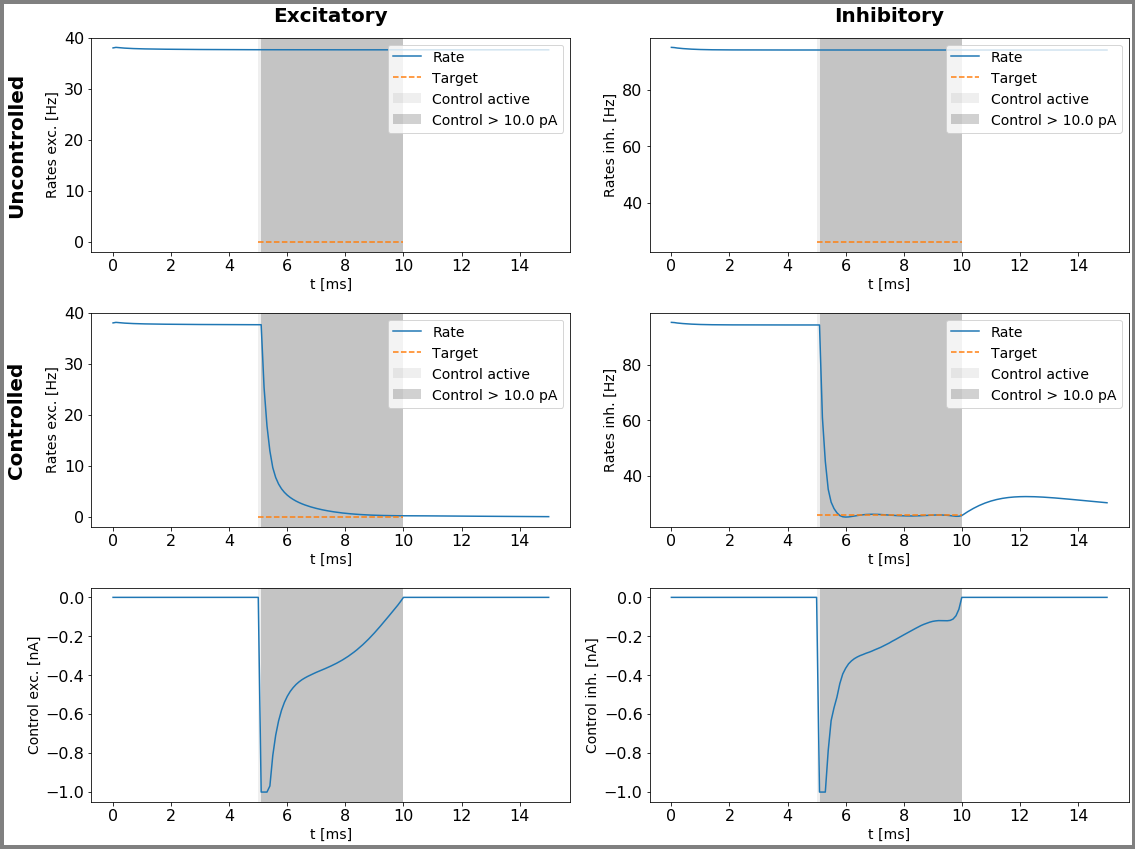

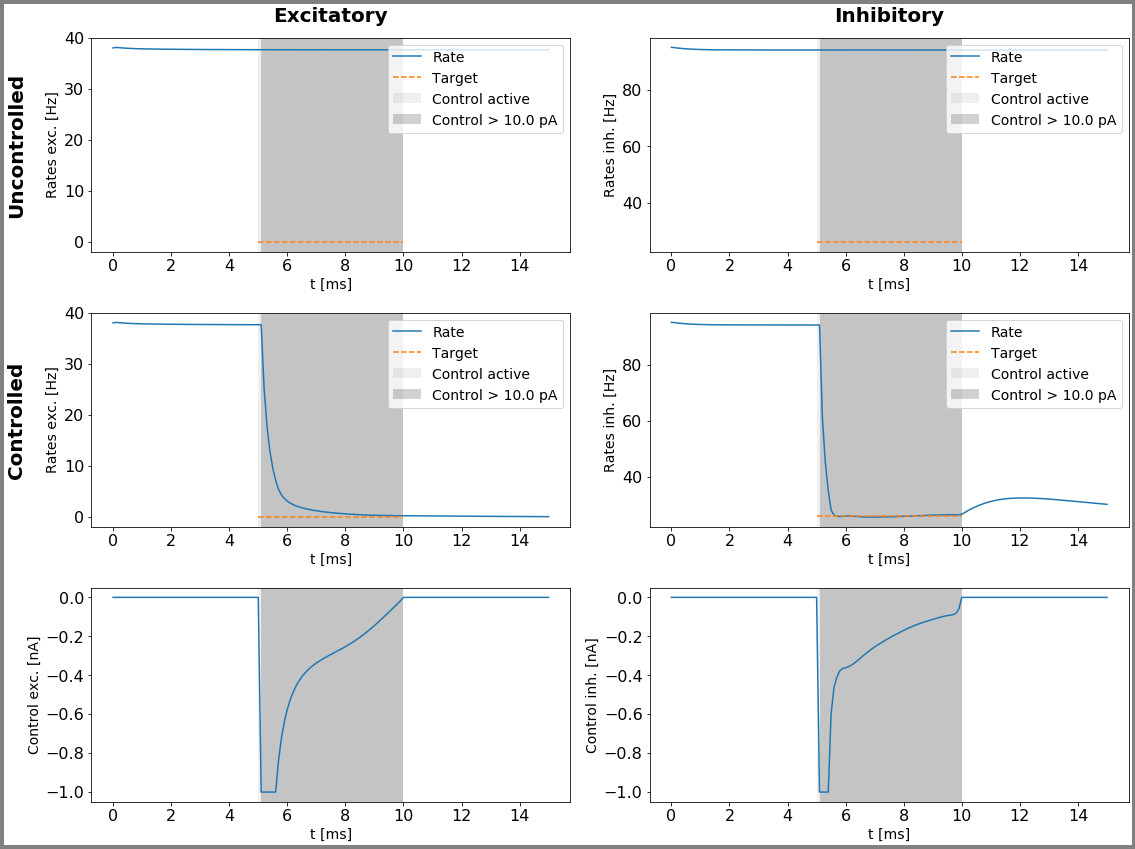

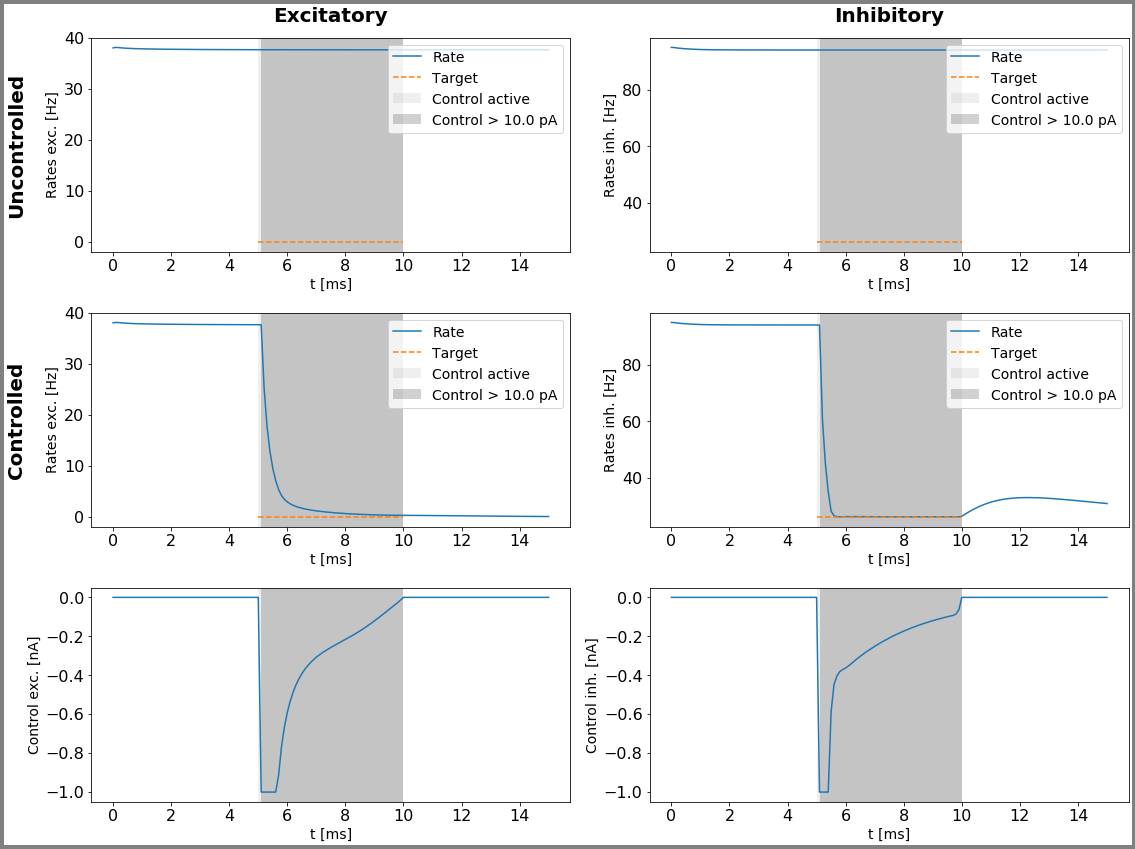

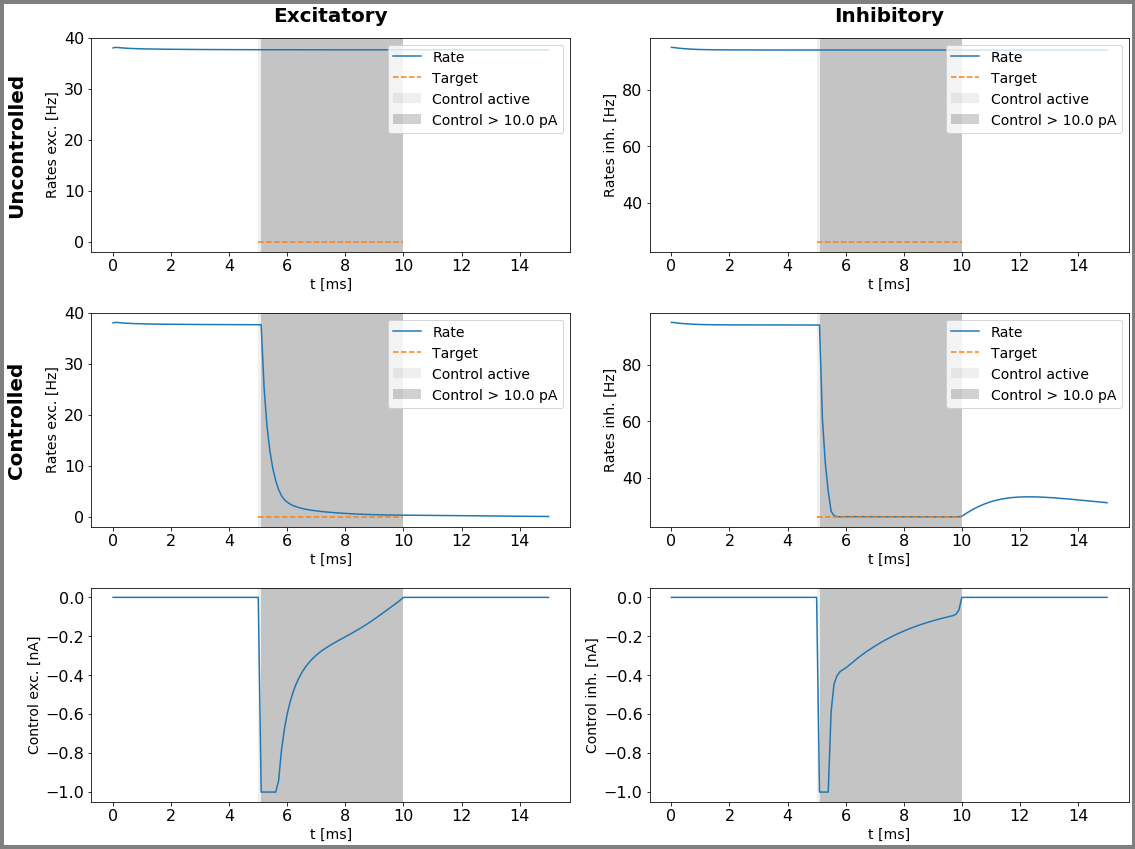

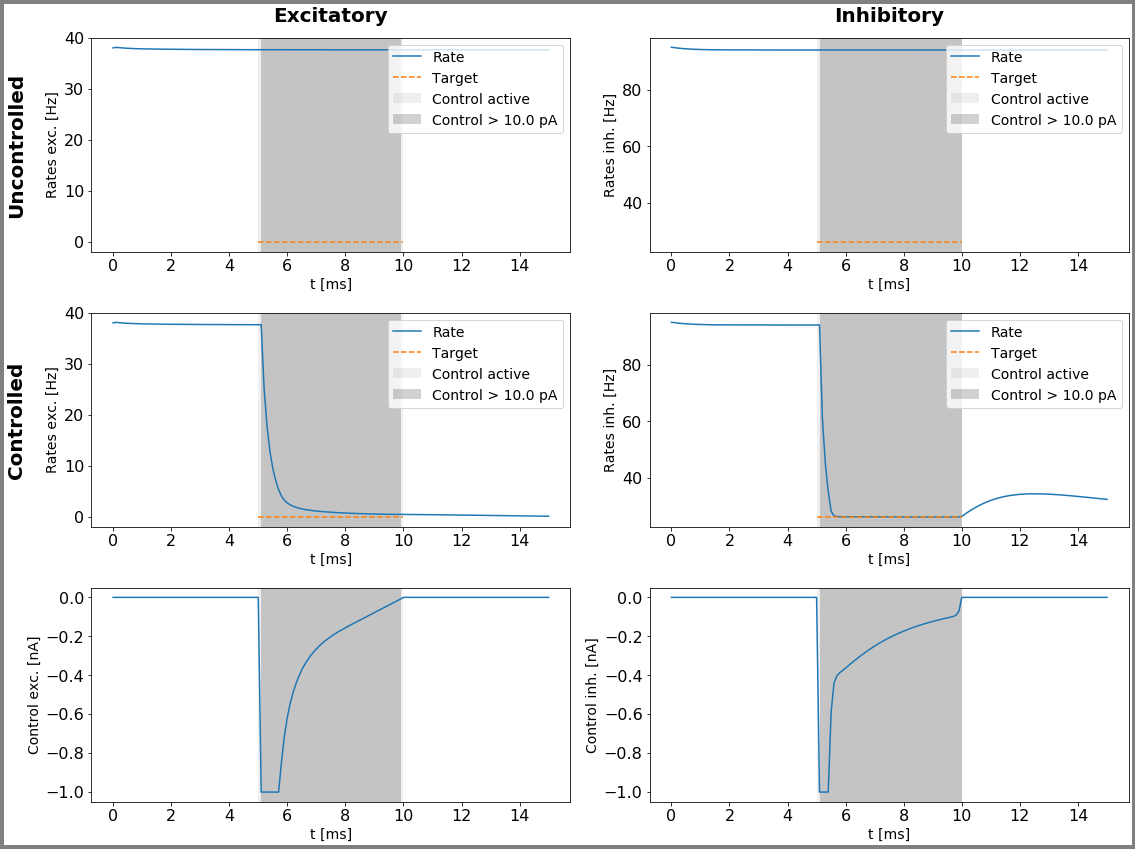

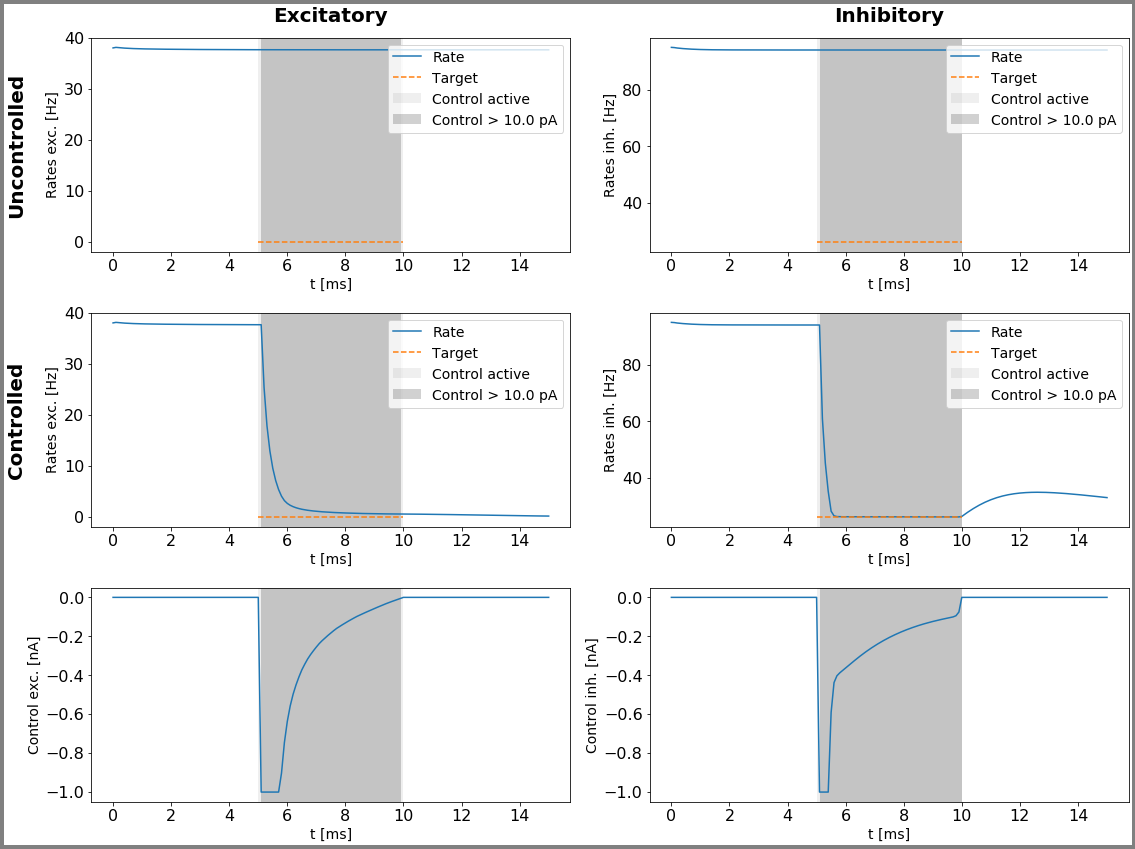

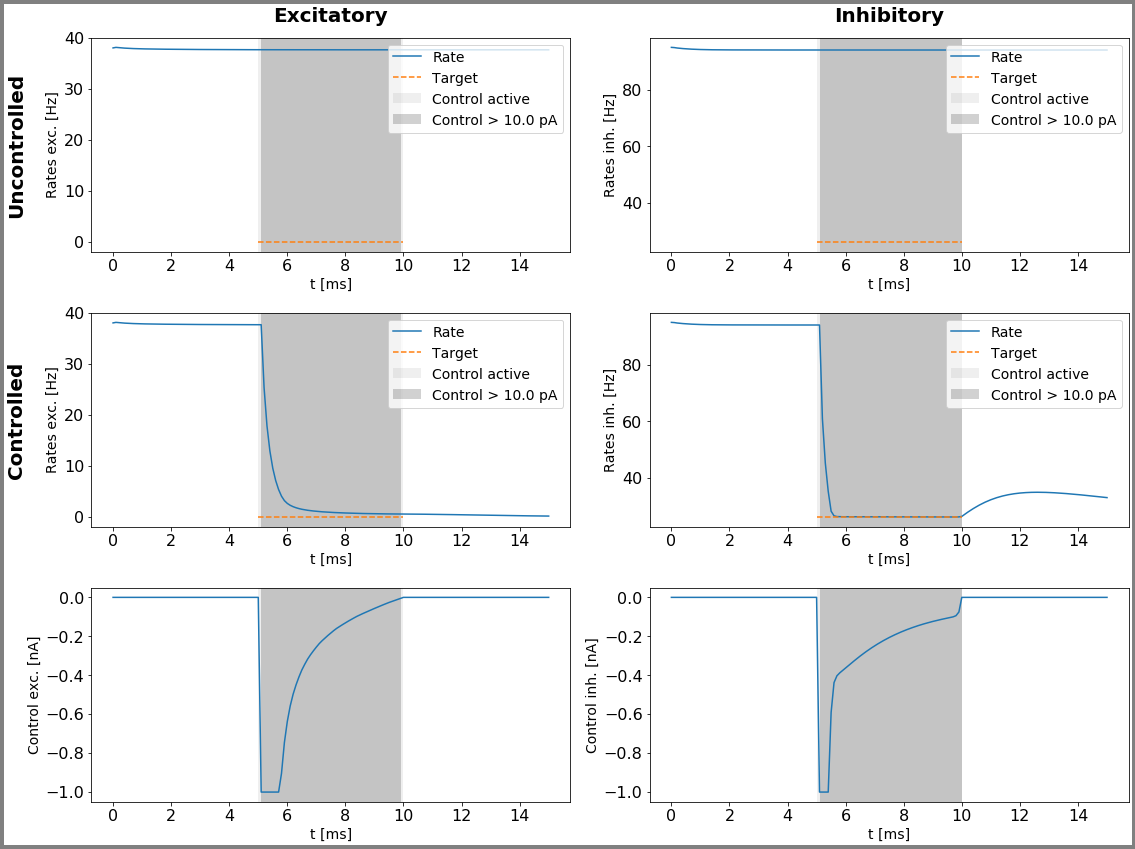

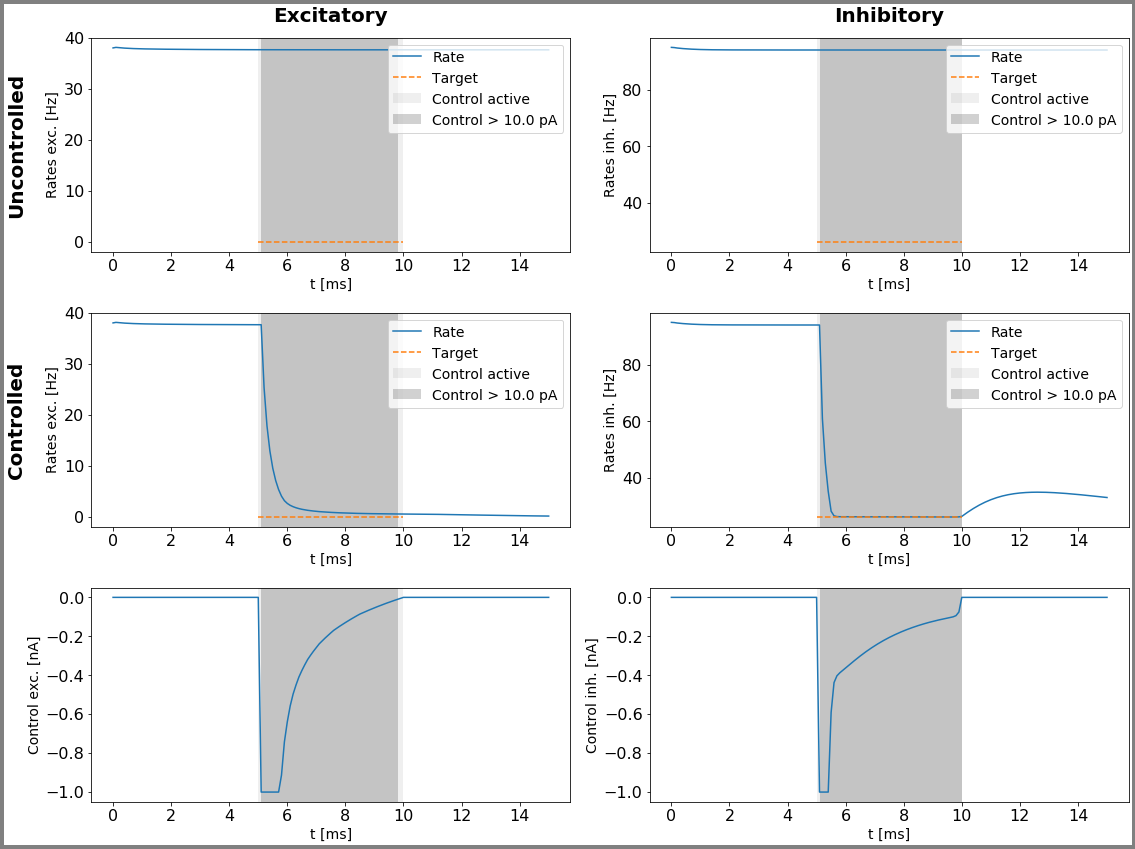

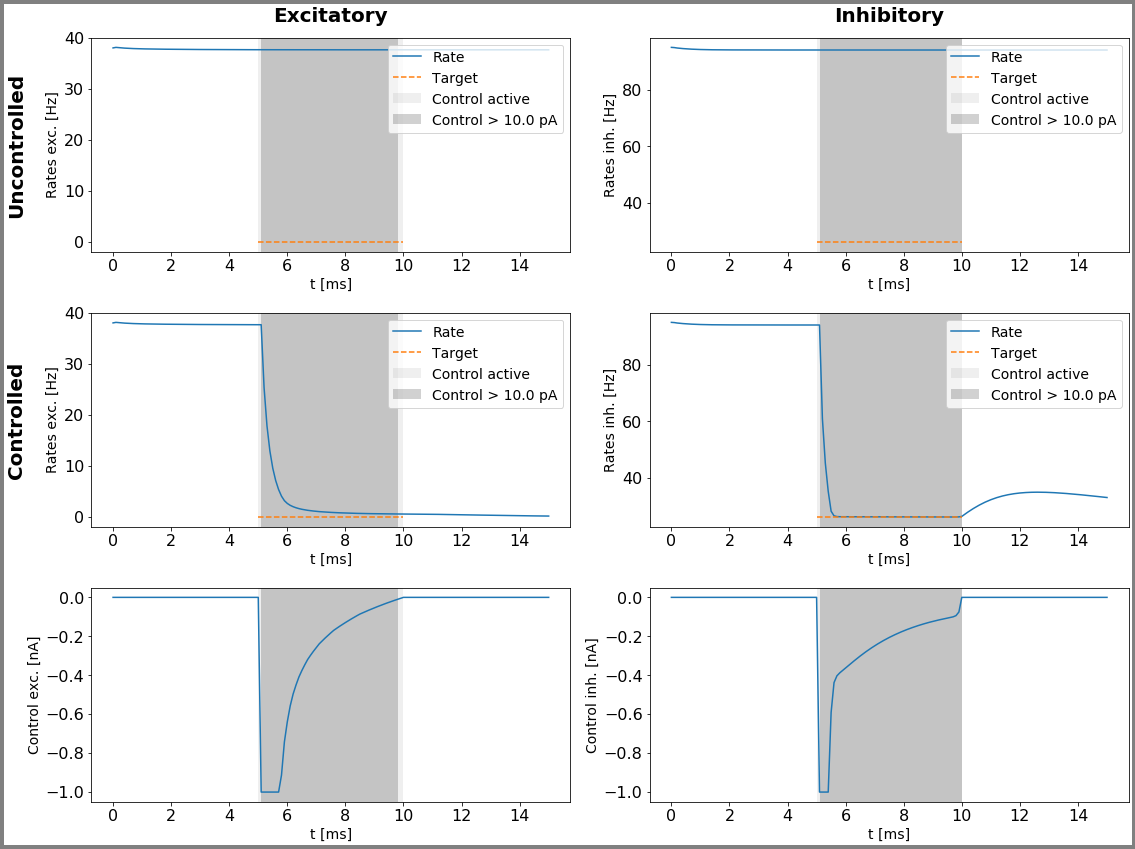

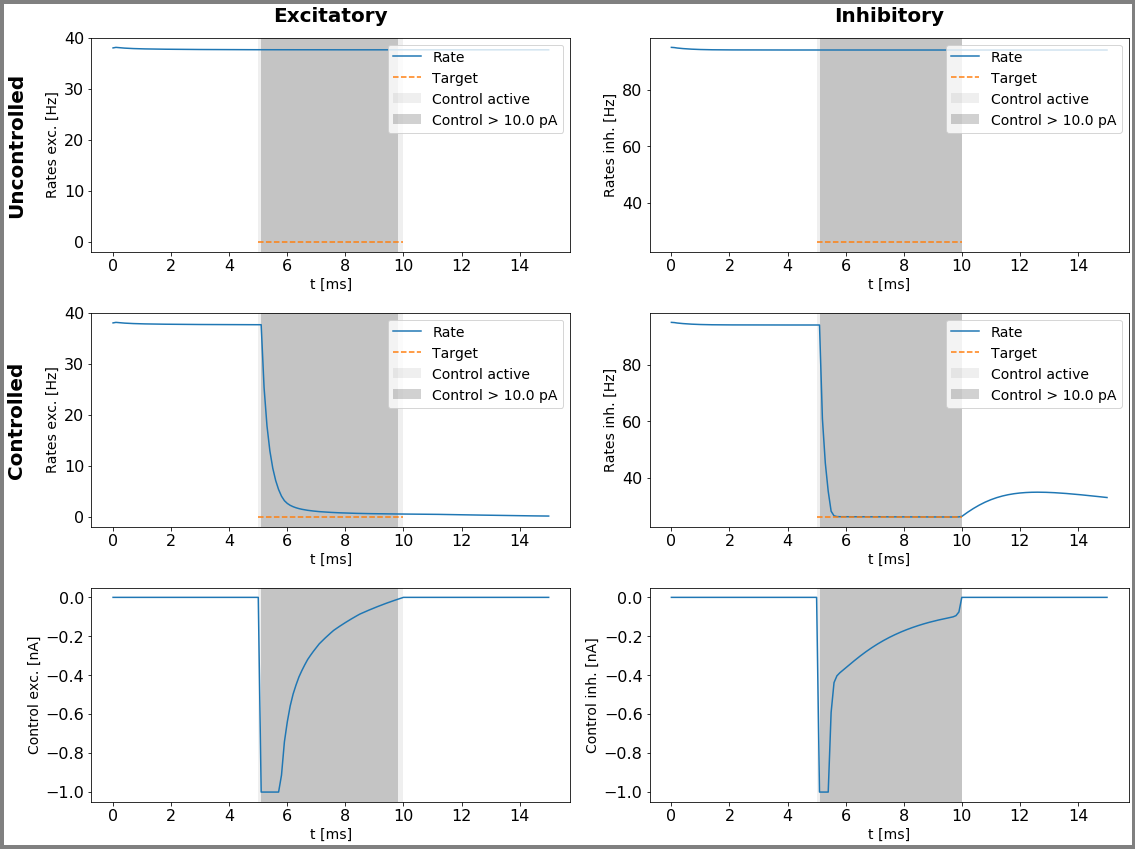

In [116]:
for i in range(loop_it):
    setinitvars(high_state_vars)
    
    cntrlA1_, bestStateA1_, costA1_, runtimeA1_, grad = aln.A1(cntrl1, target_hl, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    
    #if (i % 10 == 0):
    plotFunc.plot_control(aln, cntrlA1_, dur, dur_pre, dur_post, high_state_vars, target_hl,
                      path, filename_ = str('p1_e1_u1nA_HighLow_' + alg + "_" + str(i*max_it) ))
    
    cntrl1 = cntrlA1_[:,:,50:101]
    if i == 0:
        costA1[0] = costA1_[0]
    costA1[max_it*i+1:max_it*i+max_it+1] = costA1_[1:]
    runtimeA1[max_it*i+1:max_it*i+max_it+1] = runtimeA1[max_it*i] + runtimeA1_[1:]

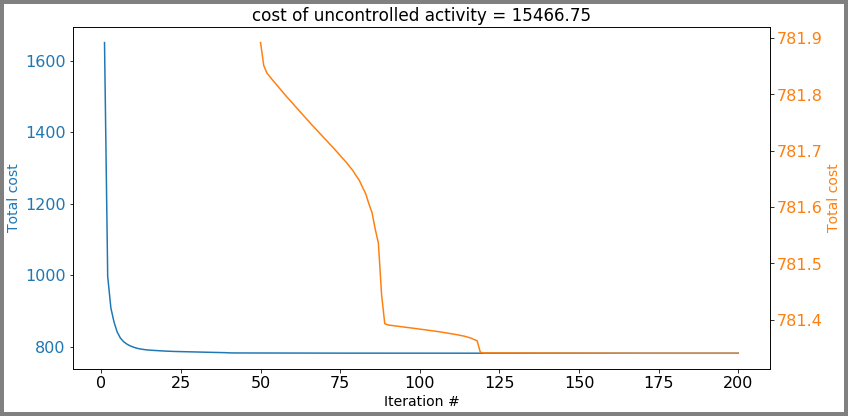

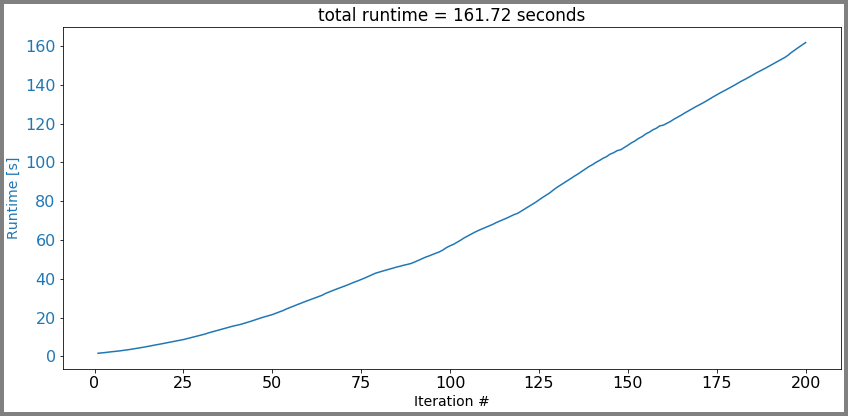

In [117]:
#print(costA1)
#print(costD)
costA1 = np.array(costA1[:])
#print(runtimeA1)
runtimeA1 = np.array(runtimeA1[:])
plotFunc.plot_convergence(costA1, path, str("p1_e1_u1nA_HighLow_cost_" + alg) )
plotFunc.plot_runtime(runtimeA1, path, str("p1_e1_u1nA_HighLow_runtime_" + alg))

In [118]:
cntrl1 = init_1nA_hl
alg = "A2"

max_it = 5
loop_it = 5
costA2 = np.zeros(max_it*loop_it + 1)
runtimeA2 = np.zeros(max_it*loop_it + 1)

True
RUN  0 , total integrated cost:  15466.745250817374
RUN  1 , total integrated cost:  1089.710862629179
RUN  2 , total integrated cost:  997.4796635832923
RUN  3 , total integrated cost:  883.9064997855198
RUN  4 , total integrated cost:  839.6810338841368
RUN  5 , total integrated cost:  817.6618564456389
Improved over  5  iterations by  95  percent.
True
RUN  0 , total integrated cost:  817.6618564456389
RUN  1 , total integrated cost:  806.1541266784424
RUN  2 , total integrated cost:  799.6230562866459
RUN  3 , total integrated cost:  795.3838289553701
RUN  4 , total integrated cost:  792.7092333584372
RUN  5 , total integrated cost:  791.0453423294568
Improved over  5  iterations by  4  percent.
True
RUN  0 , total integrated cost:  791.0453423294568
RUN  1 , total integrated cost:  789.5978869281258
RUN  2 , total integrated cost:  788.3734276928839
RUN  3 , total integrated cost:  787.312250472595
RUN  4 , total integrated cost:  786.3553679398452
RUN  5 , total integrated c

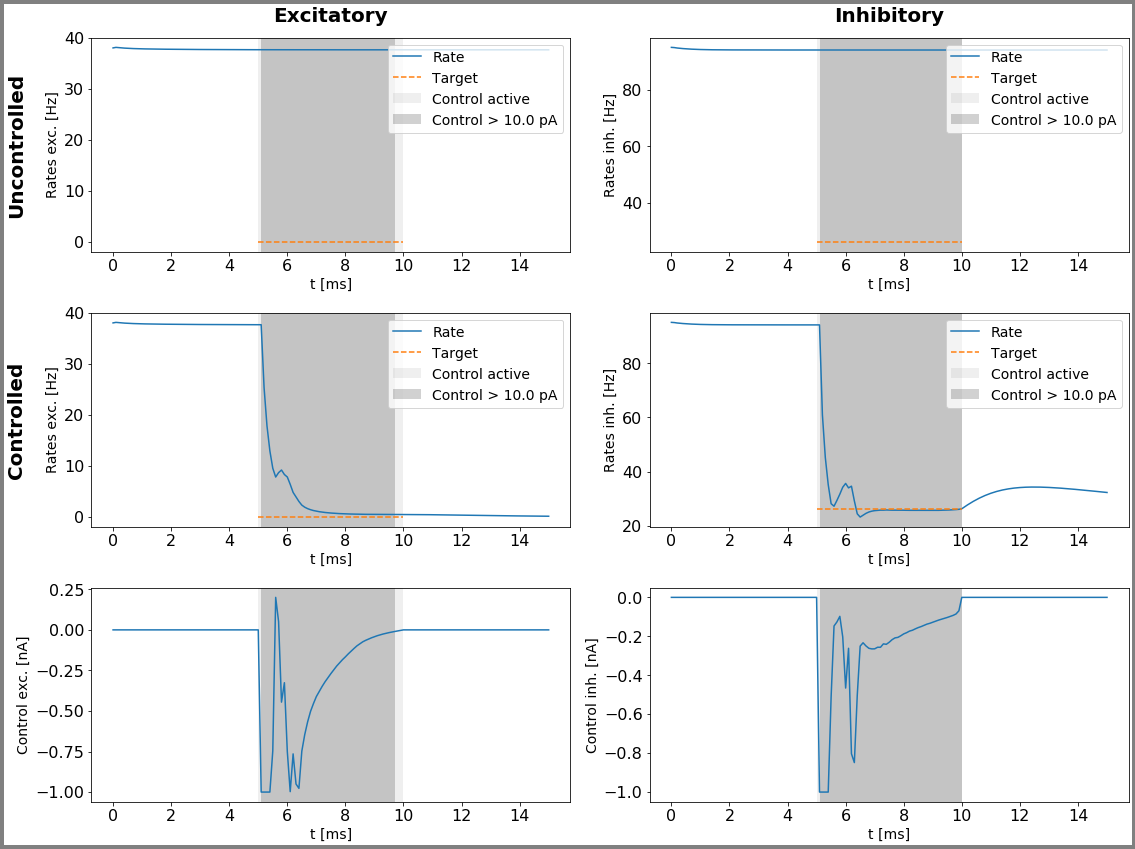

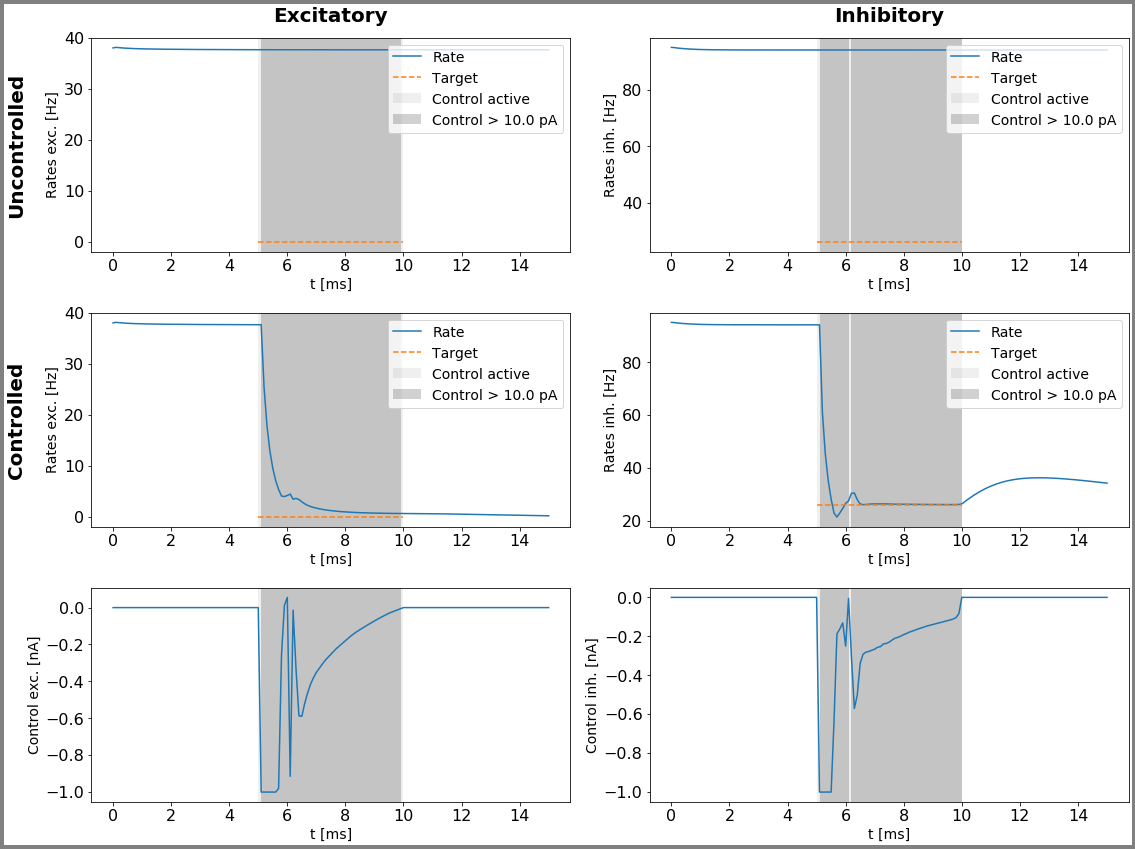

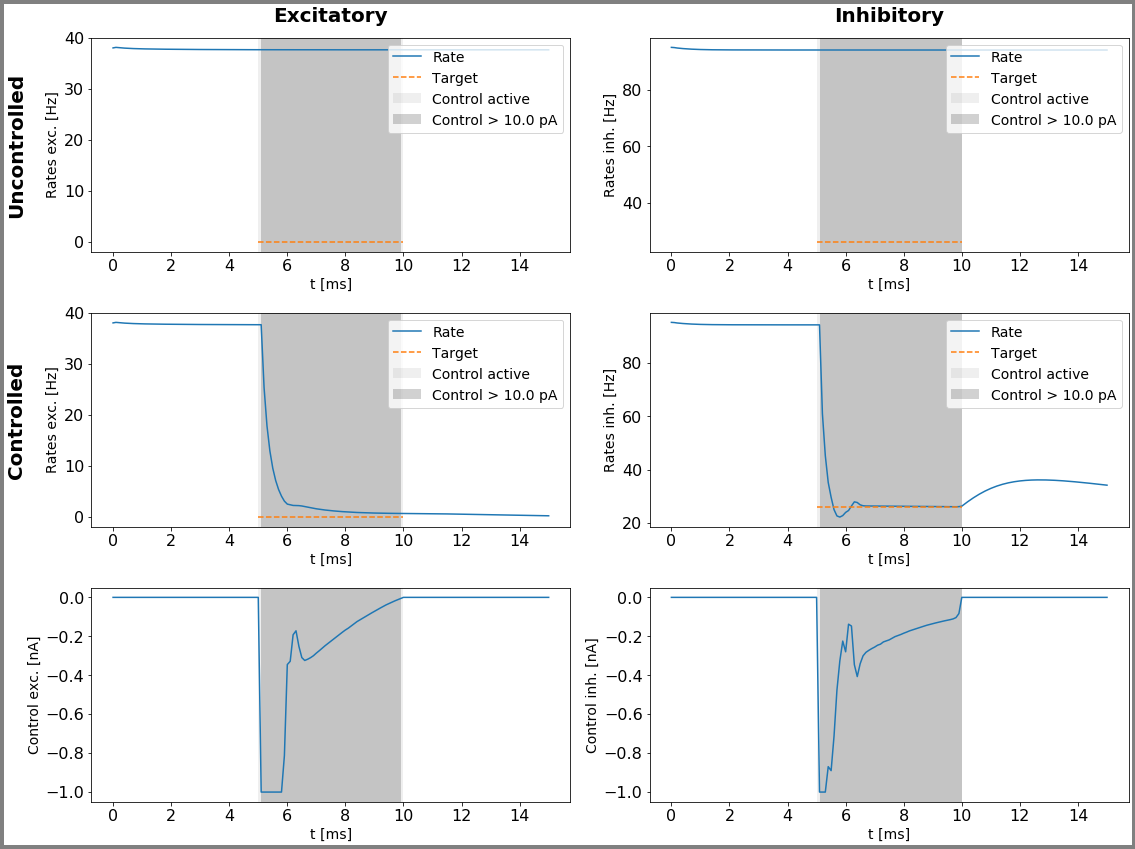

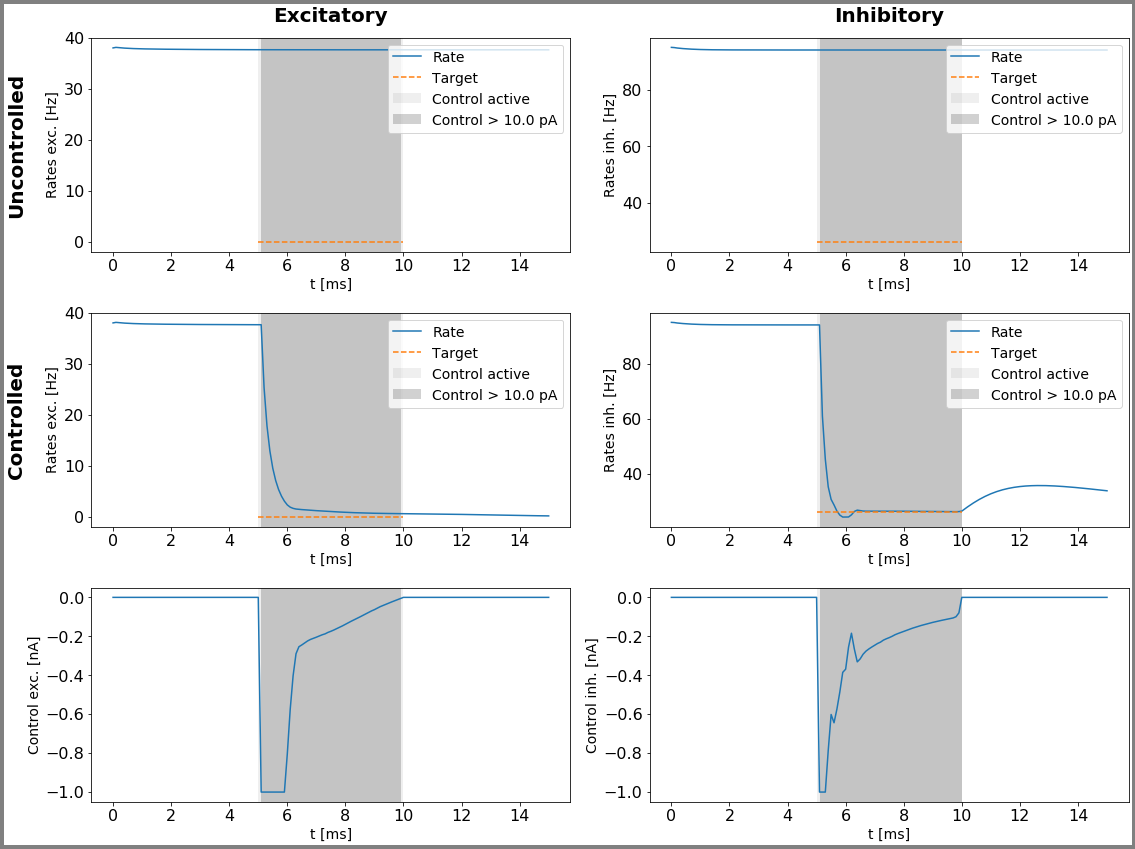

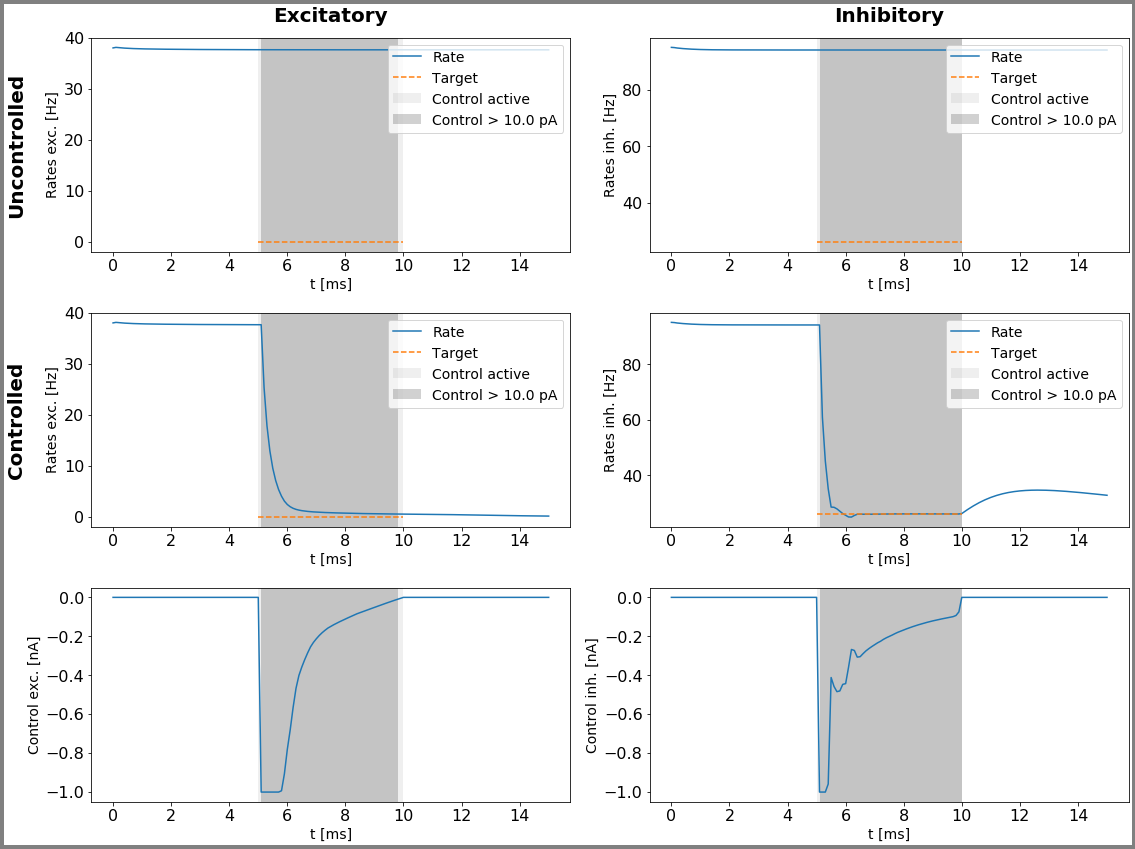

In [119]:
for i in range(loop_it):
    setinitvars(high_state_vars)
    cntrlA2_, bestStateA2_, costA2_, runtimeA2_ = aln.A2(cntrl1, target_hl, max_iteration_ = max_it, tolerance_ = tol,
                    include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                    max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)
    
    #if (i % 10 == 0):
    plotFunc.plot_control(aln, cntrlA2_, dur, dur_pre, dur_post, high_state_vars, target_hl,
                      path, filename_ = str('p1_e1_u1nA_HighLow_' + alg + "_" + str(i*max_it) ))
    
    cntrl1 = cntrlA2_[:,:,50:101]
    if i == 0:
        costA2[0] = costA2_[0]
    costA2[max_it*i+1:max_it*i+max_it+1] = costA2_[1:]
    runtimeA2[max_it*i+1:max_it*i+max_it+1] = runtimeA2[max_it*i] + runtimeA2_[1:]

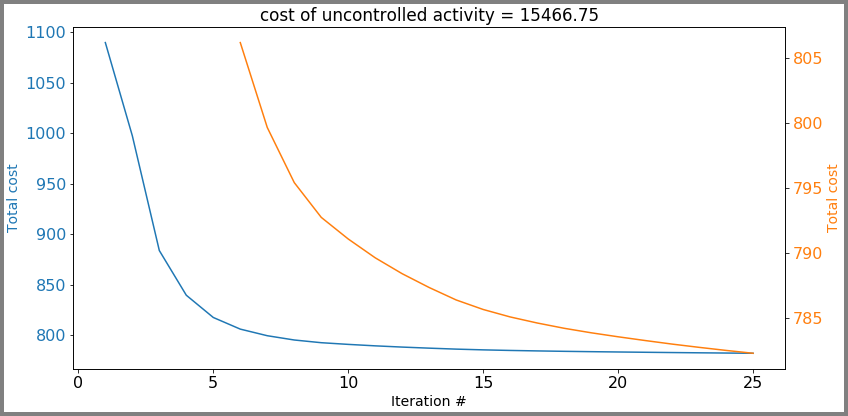

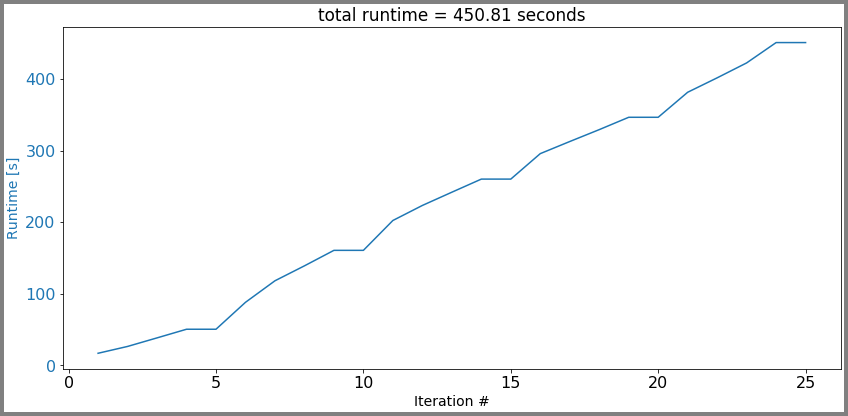

In [120]:
costA2 = np.array(costA2[:])
runtimeA2 = np.array(runtimeA2[:])
plotFunc.plot_convergence(costA2, path, str("p1_e1_u1nA_HighLow_cost_" + alg) )
plotFunc.plot_runtime(runtimeA2, path, str("p1_e1_u1nA_HighLow_runtime_" + alg))

cost A1 =  781.3405276744785
cost A2 =  782.2557631777604
runtime A1 =  161.7188474999857
runtime A2 =  450.8073340000119


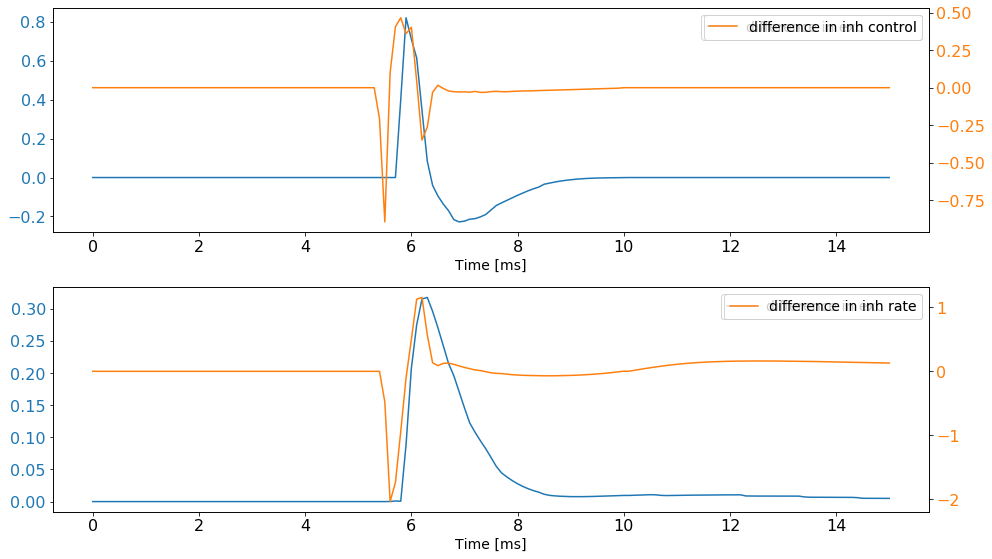

In [122]:
diff_cntrl = (cntrlA1_ - cntrlA2_)
diff_state = (bestStateA1_[:,:3,:] - bestStateA2_)
diff_cost = costA1[-1] - costA2[-1]
diff_runtime = runtimeA1[-1] - runtimeA2[-1]

print("cost A1 = ", costA1[-1])
print("cost A2 = ", costA2[-1])
print("runtime A1 = ", runtimeA1[-1])
print("runtime A2 = ", runtimeA2[-1])

fig, axes = plt.subplots(2, figsize=(14, 8))

color = 'tab:blue'
axes[0].set_xlabel('Time [ms]')
axes[0].plot(aln.t, diff_cntrl[0,0,:], label="difference in exc control", color=color)
axes[0].tick_params(axis='y', labelcolor=color)
axes[1].set_xlabel('Time [ms]')
axes[1].plot(aln.t, diff_state[0,0,:], label="difference in exc rate", color=color)
axes[1].tick_params(axis='y', labelcolor=color)

ax1 = axes[0].twinx() 
color = 'tab:orange'
ax1.plot(aln.t, diff_cntrl[0,1,:], label="difference in inh control", color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = axes[1].twinx() 
color = 'tab:orange'
ax2.plot(aln.t, diff_state[0,1,:], label="difference in inh rate", color=color)
ax2.tick_params(axis='y', labelcolor=color)

for i in range(2):
    axes[i].legend()
ax1.legend()
ax2.legend()
    
fig.tight_layout()  # otherwise the right y-label is slightly clipped

plt.savefig(os.path.join(path,"p1_e1_u1nA_HighLow_compare"))